In [ ]:
library(isoviz)

In [132]:
# test CLTA!
source("/Users/kisaev/Documents/github/isoviz/R/isoviz_plot_juncs_to_iso.R")
source("/Users/kisaev/Documents/github/isoviz/R/isoviz_rescale_introns.R")


[1] "Please ensure your input file is a PSL file~"
[1] "116566 transcripts with at least one intron!"
[1] "91946 transcripts with at least one intron!"
[1] "Printing dimensions of intron data file"
[1] 722863     10
[1] "Printing summary of intron-cluster sizes = how many junctions across in clusters"
[1] "Printing summary of intron-cluster sizes = how many junctions across in clusters"


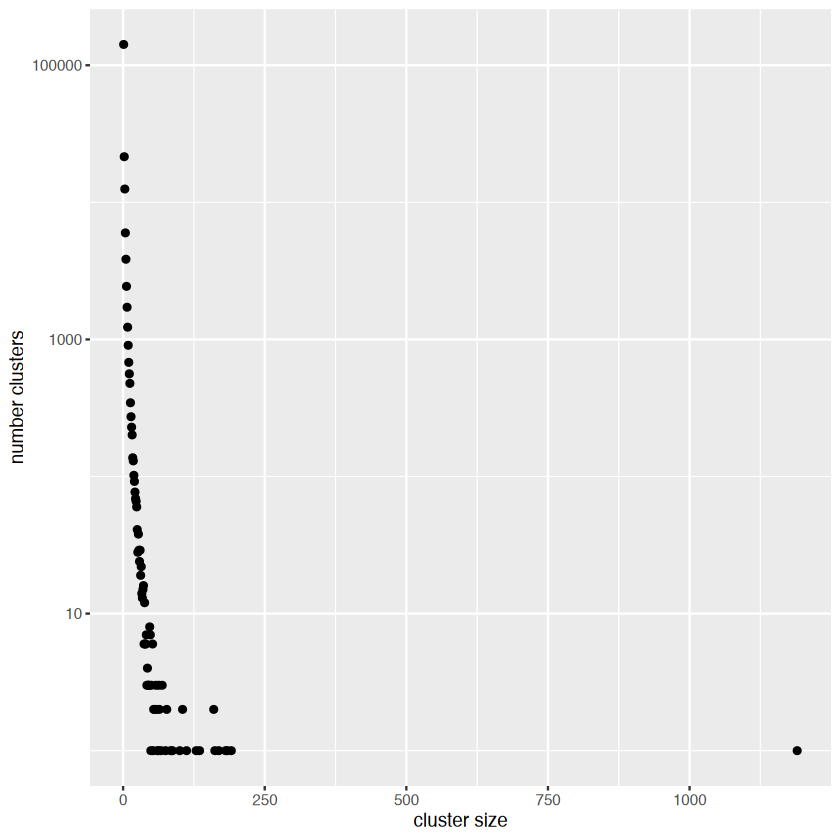

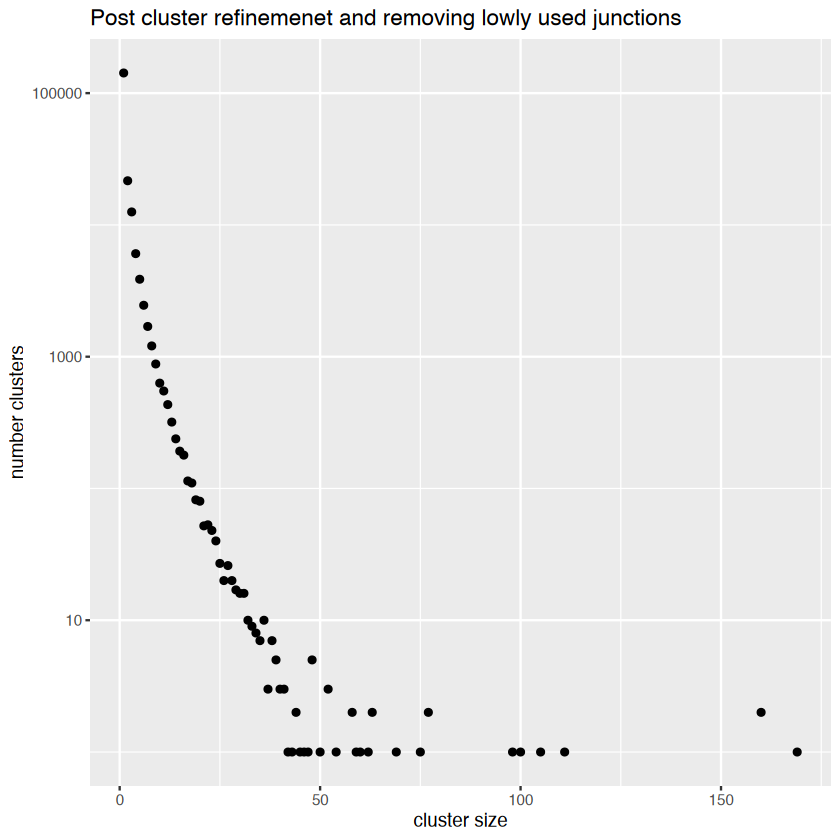

In [13]:
## default input file
file_path <- system.file("data", "gencode.v41.basic.annotation.psl", package="isoviz")
gene_trans <- system.file("data", "gencode_v41_gene_transcript_convert.txt", package="isoviz")

all_coordinates <- isoviz_coords(file_path, gene_trans) #use default genome .psl file  

exon_coords <- all_coordinates[[1]]
intron_coords <- all_coordinates[[2]]
junctions_hESC <- system.file("data", "hESC.junc.txt", package="isoviz")
intron_clusts <- isoviz_minicutter(juncs_file = junctions_hESC)
intron_annotations <- system.file("data", "gencode_intron_all_data.rda", package="isoviz")
load(intron_annotations)

In [155]:
gene = "RBFOX2"
gene_exons <- filter(exon_coords, gene_name == gene) # exon_coords from Step 1
gene_introns <- filter(intron_coords, gene_name == gene) # intron_coords from Step 1

# intron_clusts and gencode_intron_all_data from Step 2
mapped_junctions = isoviz_map_junctions(cell_type = "hESC", gene_introns, intron_clusts, gencode_intron_all_data) 

[1] "removing junction IDs obtained from clustering introns, using default names from gencode file"


In [156]:
# junctions for testing
include_specific_isoforms = c("CLTA-206", "CLTA-202", "CLTA-203", "CLTA-201", "CLTA-207", "CLTA-210", "CLTA-209", "CLTA-204")
#include_specific_junctions = c("junc14350", "junc14344", "junc14341", "junc14340", 
#"junc14337", "junc14332", "junc14331", "junc14330")


Ref transcript: RBFOX2-209 
[1] "getting ref coordinates"


Adding missing grouping variables: `cluster_idx`
Joining with `by = join_by(chr, intron_starts, intron_ends, strand,
junc.counts, cluster_idx, junction_category, junc_id, junc.per.cluster,
junc.usage)`
Warning message in `[.data.table`(to_plot_ordered, , `:=`(exon_number, seq_len(.N)), :
"A shallow copy of this data.table was taken so that := can add or remove 1 columns by reference. At an earlier point, this data.table was copied by R (or was created manually using structure() or similar). Avoid names<- and attr<- which in R currently (and oddly) may copy the whole data.table. Use set* syntax instead to avoid copying: ?set, ?setnames and ?setattr. It's also not unusual for data.table-agnostic packages to produce tables affected by this issue. If this message doesn't help, please report your use case to the data.table issue tracker so the root cause can be fixed or this message improved."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom

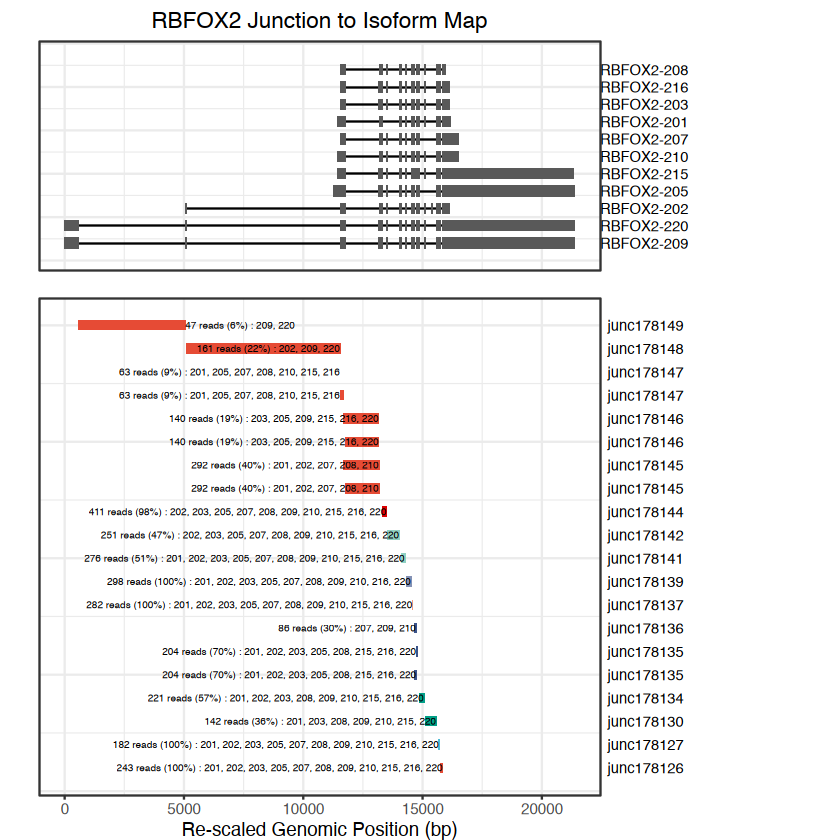

In [160]:
isoviz_plot_juncs_to_iso(mapped_junctions, gene_exons, gene_introns,
                                    cell_type = "hESC",
                                    #include_specific_isoforms = include_specific_isoforms, 
                                    #include_specific_junctions = include_specific_junctions,
                                    junc_usage = 5, #min junc usage to be included 
                                    intron_scale = "yes", 
                                    intron_scale_width = 20
                                    )

Adding missing grouping variables: `cluster_idx`
Joining with `by = join_by(chr, intron_starts, intron_ends, strand,
junc.counts, cluster_idx, junction_category, junc_id, junc.per.cluster,
junc.usage)`
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_rect()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text()`)."


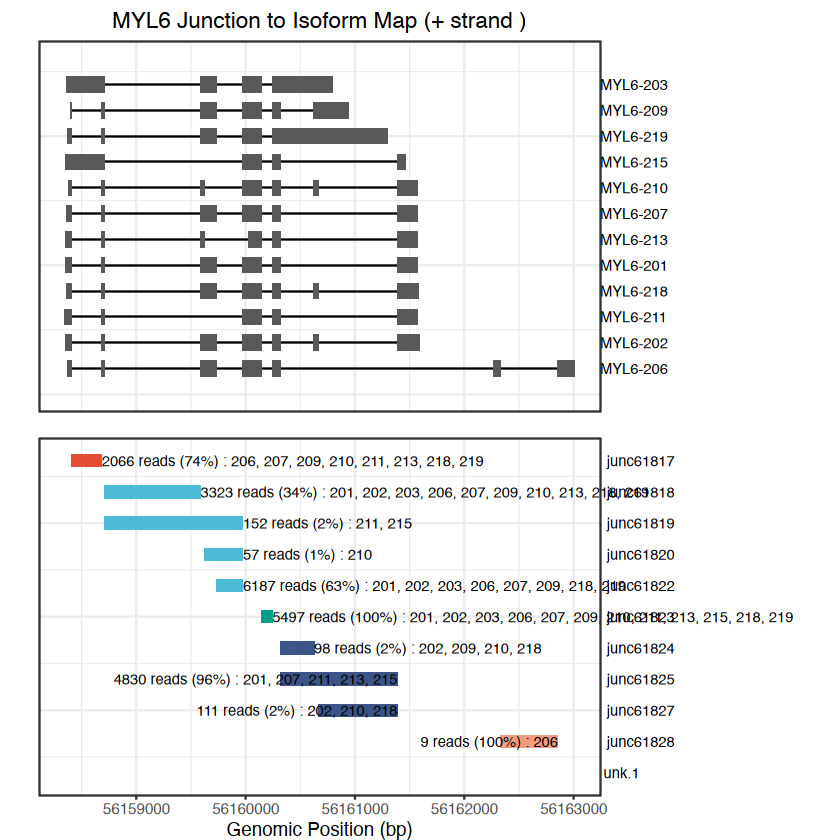

In [148]:
isoviz_plot_juncs_to_iso(mapped_junctions, gene_exons, gene_introns,
                                    cell_type = "hESC",
                                    #include_specific_isoforms = include_specific_isoforms, 
                                    #include_specific_junctions = include_specific_junctions,
                                    junc_usage = 1, #min junc usage to be included 
                                    intron_scale = "no", 
                                    intron_scale_width = 10
                                    )